In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Optional — for clustering bonus
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13

FEAR_COLOR  = '#e74c3c'
GREED_COLOR = '#2ecc71'
PALETTE     = {'Fear': FEAR_COLOR, 'Greed': GREED_COLOR}

print('All imports OK')

All imports OK


In [3]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Load datasets
# Adjust filenames if yours differ
FG_FILE     = '/content/fear_greed_index.csv'
TRADER_FILE = '/content/historical_data.csv'

fg_raw     = pd.read_csv(FG_FILE)
trader_raw = pd.read_csv(TRADER_FILE)

print('=== Fear/Greed Dataset ===')
print(f'Shape: {fg_raw.shape}')
print(fg_raw.head(3))
print()
print('=== Trader Dataset ===')
print(f'Shape: {trader_raw.shape}')
print(trader_raw.head(3))

=== Fear/Greed Dataset ===
Shape: (2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

=== Trader Dataset ===
Shape: (211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418

In [8]:
def audit(df, name):#row/column counts and missing values , duplicates
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  Rows    : {df.shape[0]:,}')
    print(f'  Columns : {df.shape[1]}')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f'  Missing values:')
        for col, cnt in missing.items():
            print(f'    {col}: {cnt} ({cnt/len(df)*100:.1f}%)')
    else:
        print('  Missing values: None')
    dupes = df.duplicated().sum()
    print(f'  Duplicate rows: {dupes}')

audit(fg_raw, 'Fear/Greed')
audit(trader_raw, 'Trader Data')


  Fear/Greed
  Rows    : 2,644
  Columns : 4
  Missing values: None
  Duplicate rows: 0

  Trader Data
  Rows    : 211,224
  Columns : 16
  Missing values: None
  Duplicate rows: 0


In [10]:
fg = fg_raw.copy()#for fear and greed

# Try common date column names
date_col_candidates = ['date', 'Date', 'DATE', 'timestamp', 'Timestamp']
fg_date_col = next((c for c in date_col_candidates if c in fg.columns), fg.columns[0])
fg['date'] = pd.to_datetime(fg[fg_date_col], infer_datetime_format=True, errors='coerce')
fg['date'] = fg['date'].dt.normalize()

# Sentiment column
sent_col_candidates = ['classification', 'Classification', 'sentiment', 'Sentiment', 'label', 'Label']
sent_col = next((c for c in sent_col_candidates if c in fg.columns), fg.columns[1])
fg['sentiment'] = fg[sent_col].str.strip().str.title()   # 'Fear' / 'Greed'

fg = fg[['date', 'sentiment']].dropna().drop_duplicates('date')
print(f'Fear/Greed date range: {fg.date.min()} → {fg.date.max()}')
print(fg['sentiment'].value_counts())

Fear/Greed date range: 2018-02-01 00:00:00 → 2025-05-02 00:00:00
sentiment
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [15]:
tr = trader_raw.copy()#for trwder data

# Auto-detect timestamp column
ts_candidates = ['time', 'Time', 'timestamp', 'Timestamp', 'date', 'Date', 'created_at']
ts_col = next((c for c in ts_candidates if c in tr.columns), tr.columns[0])

# Handle epoch ms vs string
if pd.api.types.is_numeric_dtype(tr[ts_col]):
    # Likely epoch milliseconds
    tr['date'] = pd.to_datetime(tr[ts_col], unit='ms', errors='coerce').dt.normalize()
else:
    tr['date'] = pd.to_datetime(tr[ts_col], infer_datetime_format=True, errors='coerce').dt.normalize()

# Standardize names (lowercase)
tr.columns = [c.lower().strip().replace(' ', '_') for c in tr.columns]

# Key columns and fallbacks
def find_col(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

pnl_col      = find_col(tr, ['closedpnl', 'closed_pnl', 'pnl', 'realized_pnl'])
size_col     = find_col(tr, ['sz', 'size', 'quantity', 'qty'])
side_col     = find_col(tr, ['side', 'direction', 'type'])
lev_col      = find_col(tr, ['leverage', 'lev'])
account_col  = find_col(tr, ['account', 'user', 'trader', 'address'])
symbol_col   = find_col(tr, ['coin', 'symbol', 'asset', 'market'])

print(f'Detected columns → pnl:{pnl_col}, size:{size_col}, side:{side_col}, leverage:{lev_col}, account:{account_col}')
print(f'Trader date range: {tr.date.min()} → {tr.date.max()}')
print(f'Rows after timestamp parse: {len(tr):,}')

Detected columns → pnl:closed_pnl, size:None, side:side, leverage:None, account:account
Trader date range: 2023-03-28 00:00:00 → 2025-06-15 00:00:00
Rows after timestamp parse: 211,224


In [19]:
#Cleaning trader data
tr = tr.dropna(subset=['date'])
for col in [pnl_col, size_col, lev_col]:
    if col and col in tr.columns:
        tr[col] = pd.to_numeric(tr[col], errors='coerce')

before = len(tr)
tr = tr.drop_duplicates()
print(f'Removed {before - len(tr)} duplicate rows. Remaining: {len(tr):,}')

# Standardize  column
if side_col:
    tr['side_std'] = tr[side_col].astype(str).str.upper().str.strip()
    tr['is_long'] = tr['side_std'].str.contains('BUY|LONG', regex=True).astype(int)
else:
    tr['is_long'] = np.nan

# Rename for convenience, checking if source columns exist
rename_map = {}
if pnl_col and pnl_col in tr.columns:
    rename_map[pnl_col] = 'pnl'
if size_col and size_col in tr.columns:
    rename_map[size_col] = 'size'
if lev_col and lev_col in tr.columns:
    rename_map[lev_col] = 'leverage'
if account_col and account_col in tr.columns:
    rename_map[account_col] = 'account'

tr = tr.rename(columns=rename_map)

# Create 'win' column, checking if 'pnl' exists after renaming
if 'pnl' in tr.columns:
    tr['win'] = (tr['pnl'] > 0).astype(int)
else:
    tr['win'] = np.nan # Assign NaN or handle as appropriate if 'pnl' is missing

# Dynamically build the list of columns to print based on existence
columns_to_print = ['date', 'account']
if 'pnl' in tr.columns:
    columns_to_print.append('pnl')
if 'size' in tr.columns:
    columns_to_print.append('size')
if 'leverage' in tr.columns:
    columns_to_print.append('leverage')
if 'is_long' in tr.columns:
    columns_to_print.append('is_long')
if 'win' in tr.columns:
    columns_to_print.append('win')

print(tr[columns_to_print].head())

Removed 0 duplicate rows. Remaining: 211,224
        date                                     account  pnl  is_long  win
0 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0        1    0
1 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0        1    0
2 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0        1    0
3 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0        1    0
4 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0        1    0


In [21]:
#Merge datasets on date
tr_merged = tr.merge(fg, on='date', how='inner')
print(f'After merge: {len(tr_merged):,} trades across {tr_merged.date.nunique()} days')
print(f'Sentiment coverage: {tr_merged.sentiment.value_counts().to_dict()}')

After merge: 184,263 trades across 6 days
Sentiment coverage: {'Fear': 133871, 'Greed': 36289, 'Neutral': 7141, 'Extreme Greed': 6962}


In [27]:
# Daily & per-account metrics

#Daily aggregate
daily_agg_dict = {}
if 'pnl' in tr_merged.columns:
    daily_agg_dict['total_pnl'] = ('pnl', 'sum')
    daily_agg_dict['median_pnl'] = ('pnl', 'median')
    daily_agg_dict['n_trades'] = ('pnl', 'count')
if 'win' in tr_merged.columns:
    daily_agg_dict['win_rate'] = ('win', 'mean')
if 'is_long' in tr_merged.columns:
    daily_agg_dict['long_ratio'] = ('is_long', 'mean')
if 'size' in tr_merged.columns:
    daily_agg_dict['avg_size'] = ('size', 'mean')
if 'leverage' in tr_merged.columns:
    daily_agg_dict['avg_leverage'] = ('leverage', 'mean')

daily = tr_merged.groupby(['date', 'sentiment']).agg(**daily_agg_dict).reset_index()

#daily pnl cumulative
daily = daily.sort_values('date')
daily['cum_pnl'] = daily['total_pnl'].cumsum()
daily['roll_max'] = daily['cum_pnl'].cummax()
daily['drawdown'] = daily['cum_pnl'] - daily['roll_max']

# Per-account aggregate
acct_agg_dict = {}
if 'pnl' in tr_merged.columns:
    acct_agg_dict['total_pnl'] = ('pnl', 'sum')
    acct_agg_dict['median_pnl'] = ('pnl', 'median')
    acct_agg_dict['n_trades'] = ('pnl', 'count')
if 'win' in tr_merged.columns:
    acct_agg_dict['win_rate'] = ('win', 'mean')
if 'is_long' in tr_merged.columns:
    acct_agg_dict['long_ratio'] = ('is_long', 'mean')
if 'date' in tr_merged.columns:
    acct_agg_dict['active_days'] = ('date', 'nunique')
if 'size' in tr_merged.columns:
    acct_agg_dict['avg_size'] = ('size', 'mean')
if 'leverage' in tr_merged.columns:
    acct_agg_dict['avg_leverage'] = ('leverage', 'mean')

acct = tr_merged.groupby('account').agg(**acct_agg_dict).reset_index()

# Accountsentiment
acct_sent_agg_dict = {}
if 'pnl' in tr_merged.columns:
    acct_sent_agg_dict['pnl'] = ('pnl', 'sum')
    acct_sent_agg_dict['trades'] = ('pnl', 'count')
if 'is_long' in tr_merged.columns:
    acct_sent_agg_dict['lr'] = ('is_long', 'mean')
if 'leverage' in tr_merged.columns:
    acct_sent_agg_dict['lev'] = ('leverage', 'mean')

acct_sent = tr_merged.groupby(['account', 'sentiment']).agg(**acct_sent_agg_dict).reset_index()

print('Daily metrics sample:')
print(daily.head())


Daily metrics sample:
        date      sentiment     total_pnl  median_pnl  n_trades  win_rate  \
0 2023-03-28          Greed  0.000000e+00         0.0         3  0.000000   
1 2023-11-14          Greed  1.555034e+02         0.0      1045  0.274641   
2 2024-03-09  Extreme Greed  1.769655e+05         0.0      6962  0.490089   
3 2024-07-03        Neutral  1.587424e+05         0.0      7141  0.317182   
4 2024-10-27          Greed  3.189461e+06         0.0     35241  0.451605   

   long_ratio       cum_pnl      roll_max  drawdown  
0    1.000000  0.000000e+00  0.000000e+00       0.0  
1    0.469856  1.555034e+02  1.555034e+02       0.0  
2    0.484200  1.771210e+05  1.771210e+05       0.0  
3    0.490828  3.358634e+05  3.358634e+05       0.0  
4    0.423569  3.525324e+06  3.525324e+06       0.0  


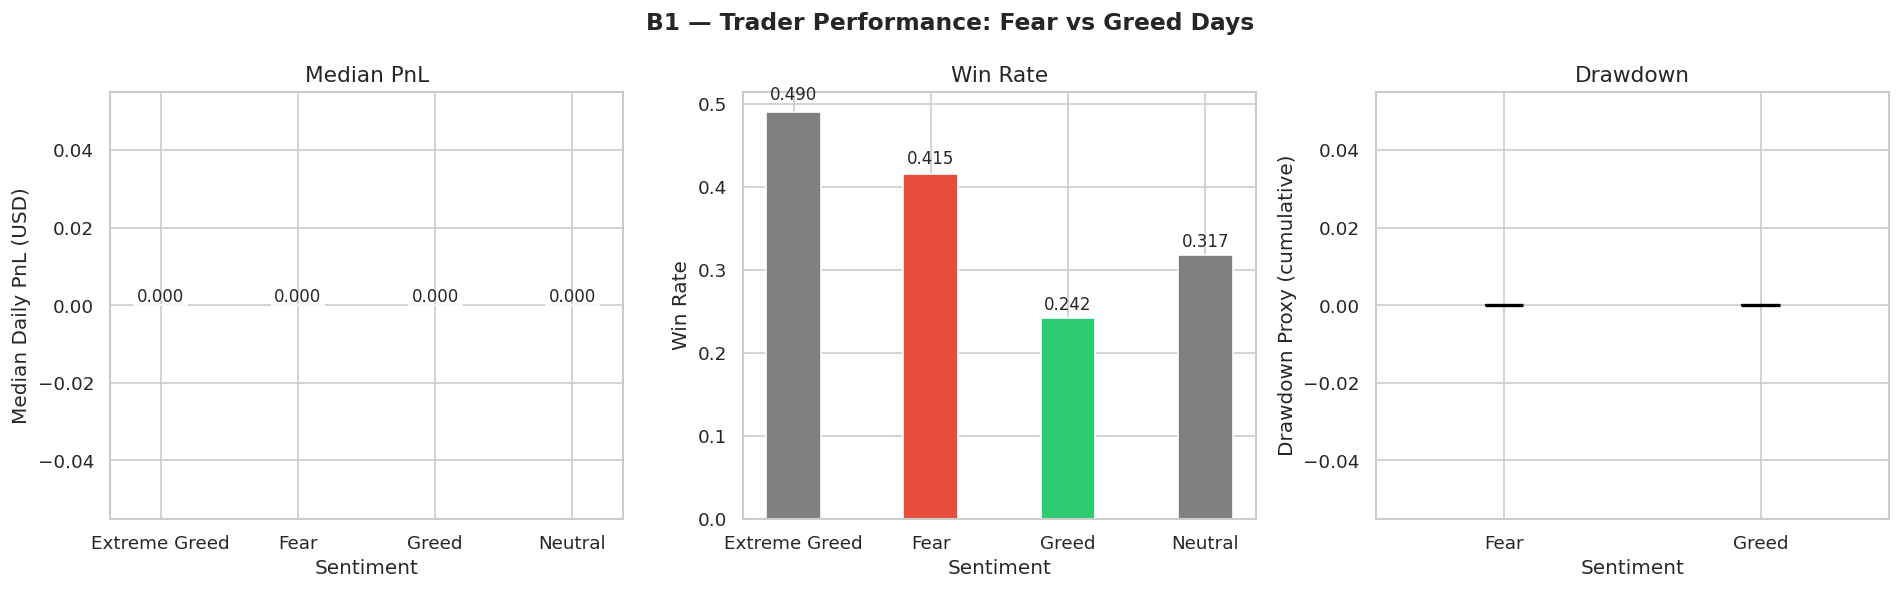

median_pnl: Fear median=0.0000, Greed median=0.0000, Mann-Whitney p=1.0000
win_rate: Fear median=0.4151, Greed median=0.2746, Mann-Whitney p=1.0000


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('B1 — Trader Performance: Fear vs Greed Days', fontsize=14, fontweight='bold')

metrics = [
    ('median_pnl',   'Median Daily PnL (USD)',  'Median PnL'),
    ('win_rate',     'Win Rate',                 'Win Rate'),
    ('drawdown',     'Drawdown Proxy (cumulative)', 'Drawdown'),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    if col == 'drawdown':
        # Box plot of drawdown
        data_fear  = daily.loc[daily.sentiment=='Fear',  col].dropna()
        data_greed = daily.loc[daily.sentiment=='Greed', col].dropna()
        bp = ax.boxplot([data_fear, data_greed], labels=['Fear','Greed'],
                        patch_artist=True, medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor(FEAR_COLOR)
        bp['boxes'][1].set_facecolor(GREED_COLOR)
    else:
        means = daily.groupby('sentiment')[col].mean()
        colors = [PALETTE.get(s, 'grey') for s in means.index]
        bars = ax.bar(means.index, means.values, color=colors, edgecolor='white', width=0.4)
        for bar, val in zip(bars, means.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Sentiment')

plt.tight_layout()
plt.savefig('chart_B1_performance.png', bbox_inches='tight')
plt.show()

# Statistical test
for col in ['median_pnl', 'win_rate']:
    fear_vals  = daily.loc[daily.sentiment=='Fear',  col].dropna()
    greed_vals = daily.loc[daily.sentiment=='Greed', col].dropna()
    t, p = stats.mannwhitneyu(fear_vals, greed_vals, alternative='two-sided')
    print(f'{col}: Fear median={fear_vals.median():.4f}, Greed median={greed_vals.median():.4f}, Mann-Whitney p={p:.4f}')

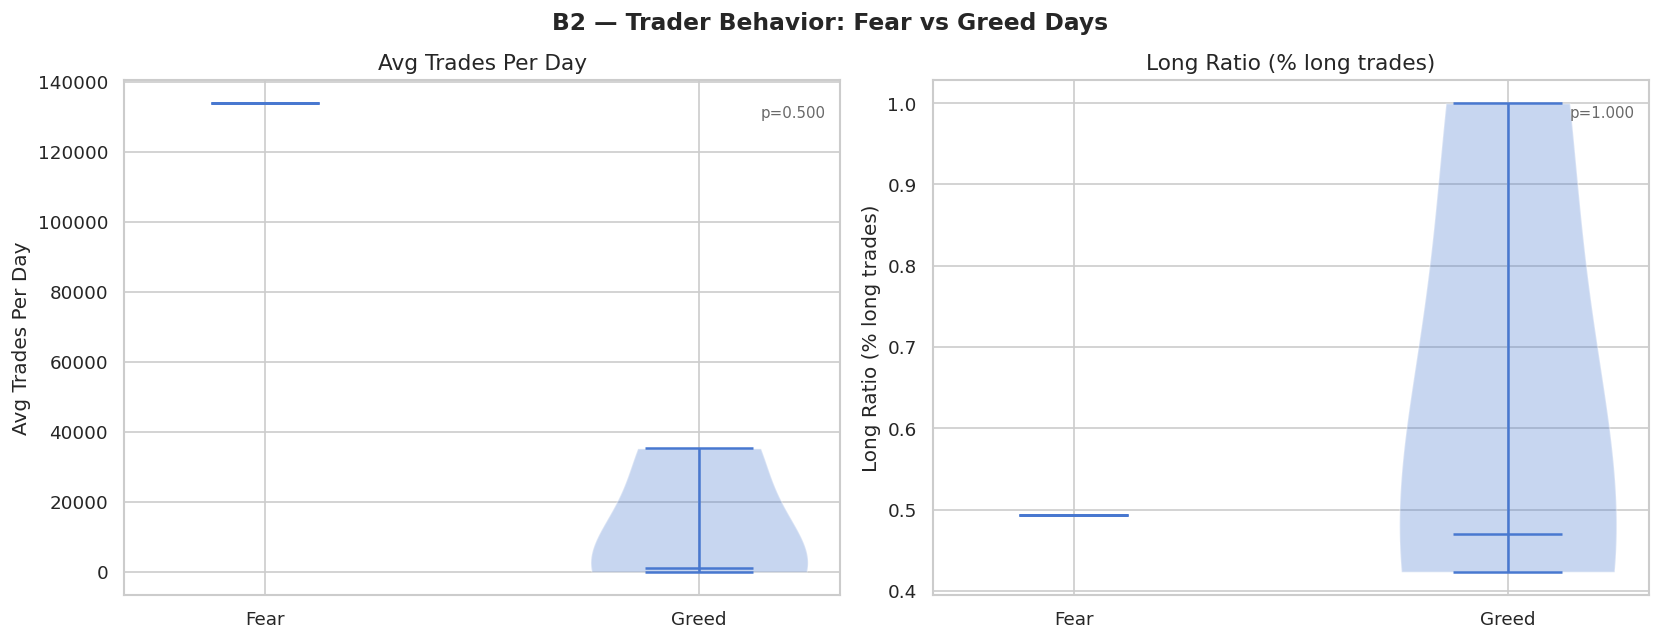

                  n_trades           long_ratio        
                      mean    median       mean  median
sentiment                                              
Extreme Greed    6962.0000    6962.0     0.4842  0.4842
Fear           133871.0000  133871.0     0.4936  0.4936
Greed           12096.3333    1045.0     0.6311  0.4699
Neutral          7141.0000    7141.0     0.4908  0.4908


In [32]:
behavior_cols_definitions = [
    ('n_trades',    'Avg Trades Per Day'),
    ('avg_leverage','Avg Leverage'),
    ('long_ratio',  'Long Ratio (% long trades)'),
    ('avg_size',    'Avg Trade Size (USD)'),
]

# Filter behavior_cols
behavior_cols = []
for col_name, display_name in behavior_cols_definitions:
    if col_name in daily.columns:
        behavior_cols.append((col_name, display_name))

if not behavior_cols:
    print("No relevant behavior columns found in 'daily' for plotting.")
else:
    # Create 2x2 subplots
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
    fig.suptitle('B2 — Trader Behavior: Fear vs Greed Days', fontsize=14, fontweight='bold')

    for i, (ax, (col, label)) in enumerate(zip(axes.flatten(), behavior_cols)):
        fear_vals  = daily.loc[daily.sentiment=='Fear',  col].dropna()
        greed_vals = daily.loc[daily.sentiment=='Greed', col].dropna()
        ax.violinplot([fear_vals, greed_vals], positions=[1, 2], showmedians=True)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Fear', 'Greed'])
        ax.set_title(label)
        ax.set_ylabel(label)
        # Annotation
        t, p = stats.mannwhitneyu(fear_vals, greed_vals, alternative='two-sided')
        ax.text(0.98, 0.95, f'p={p:.3f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='dimgrey')

    # Turn off any unused subplots
    for j in range(len(behavior_cols), len(axes.flatten())):
        fig.delaxes(axes.flatten()[j])

    plt.tight_layout()
    plt.savefig('chart_B2_behavior.png', bbox_inches='tight')
    plt.show()

# Summary table
summary_cols_to_agg = [col for col, _ in behavior_cols]
if summary_cols_to_agg:
    behavior_summary = daily.groupby('sentiment')[summary_cols_to_agg].agg(['mean','median'])
    print(behavior_summary.round(4))
else:
    print("No relevant behavior columns found in 'daily' for summary table.")


Skipping 'High vs Low Leverage' segmentation: 'avg_leverage' column not found.
Segment distributions:
  freq_segment: {'Frequent': 16, 'Infrequent': 16}
  consistent_winner: {'Inconsistent': 29, 'Consistent Winner': 3}


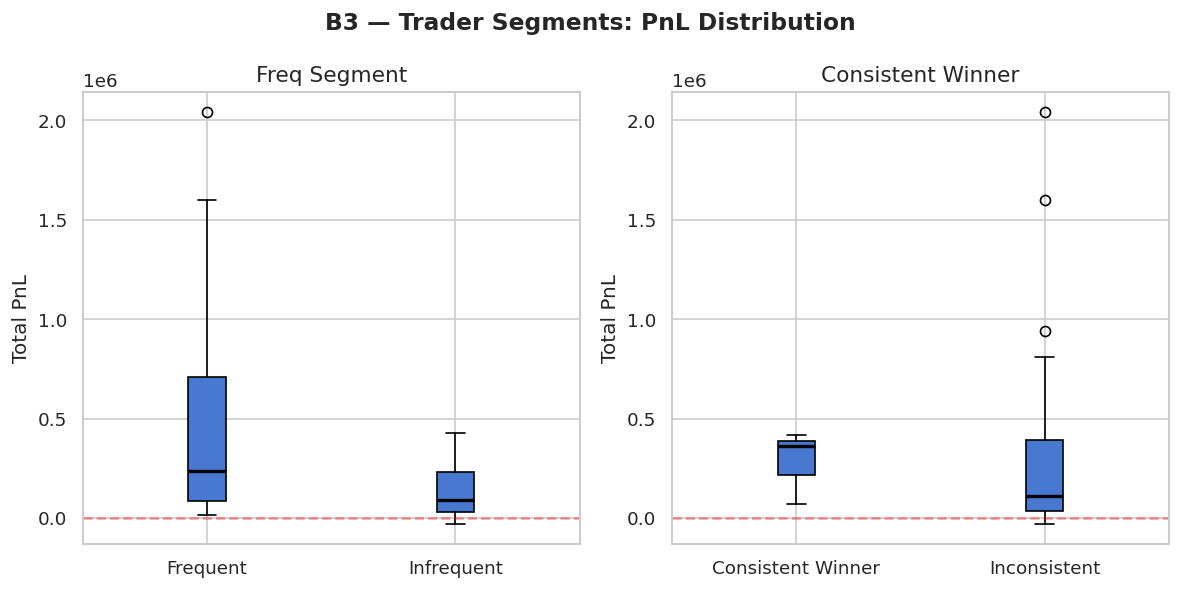

In [35]:


segments_to_plot = []

#Segment 1: High vs Low Leverage
if 'avg_leverage' in acct.columns:
    lev_median = acct['avg_leverage'].median()
    acct['lev_segment'] = np.where(acct['avg_leverage'] >= lev_median, 'High Leverage', 'Low Leverage')
    segments_to_plot.append('lev_segment')
else:
    print("Skipping 'High vs Low Leverage' segmentation: 'avg_leverage' column not found.")

#Segment 2: Frequent vs Infrequent Traders
if 'n_trades' in acct.columns:
    trade_median = acct['n_trades'].median()
    acct['freq_segment'] = np.where(acct['n_trades'] >= trade_median, 'Frequent', 'Infrequent')
    segments_to_plot.append('freq_segment')
else:
    print("Skipping 'Frequent vs Infrequent Traders' segmentation: 'n_trades' column not found.")

#Segment 3: Consistent Winners vs Inconsistent
if 'win_rate' in acct.columns and 'total_pnl' in acct.columns:
    acct['consistent_winner'] = np.where(
        (acct['win_rate'] >= 0.55) & (acct['total_pnl'] > 0), 'Consistent Winner', 'Inconsistent'
    )
    segments_to_plot.append('consistent_winner')
else:
    print("Skipping 'Consistent Winners vs Inconsistent' segmentation: 'win_rate' or 'total_pnl' column not found.")

print('Segment distributions:')
for seg in segments_to_plot:
    print(f'  {seg}: {acct[seg].value_counts().to_dict()}')

# Plot: PnL by each segment
if segments_to_plot:
    fig, axes = plt.subplots(1, len(segments_to_plot), figsize=(5 * len(segments_to_plot), 5))
    if len(segments_to_plot) == 1:
        axes = [axes] # Ensure axes is iterable even for a single subplot

    fig.suptitle('B3 — Trader Segments: PnL Distribution', fontsize=14, fontweight='bold')

    for ax, seg in zip(axes, segments_to_plot):
        groups = acct.groupby(seg)['total_pnl'].apply(list)
        labels = groups.index.tolist()
        ax.boxplot(groups.values, labels=labels, patch_artist=True,
                   medianprops=dict(color='black', linewidth=2))
        ax.set_title(seg.replace('_', ' ').title())
        ax.set_ylabel('Total PnL')
        ax.axhline(0, color='red', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig('chart_B3_segments.png', bbox_inches='tight')
    plt.show()
else:
    print("No segments could be created or plotted due to missing data.")

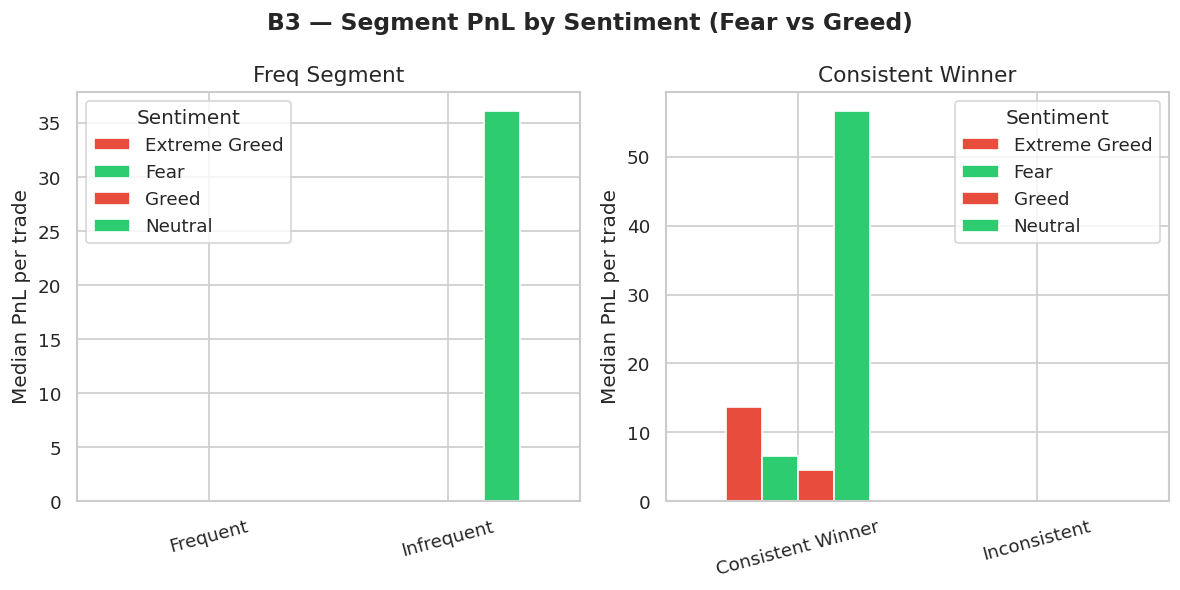

In [39]:
# Segment performance by senti
existing_segments = [seg for seg in ['lev_segment', 'freq_segment', 'consistent_winner'] if seg in acct.columns]

if not existing_segments:
    print("No segments were created in the previous step, skipping segment performance by sentiment.")
else:
    # Merge segment labels back into trade-level data, only including existing segments
    cols_to_merge = ['account'] + existing_segments
    tr_seg = tr_merged.merge(
        acct[cols_to_merge],
        on='account', how='left'
    )

    fig, axes = plt.subplots(1, len(existing_segments), figsize=(5 * len(existing_segments), 5))
    if len(existing_segments) == 1:
        axes = [axes] # Ensure axes is iterable even for a single subplot

    fig.suptitle('B3 — Segment PnL by Sentiment (Fear vs Greed)', fontsize=14, fontweight='bold')

    for ax, seg in zip(axes, existing_segments):
        pivot = tr_seg.groupby([seg,'sentiment'])['pnl'].median().unstack()
        # Handle cases where a pivot might be empty or all NaN for a sentiment
        if not pivot.empty:
            pivot.plot(kind='bar', ax=ax, color=[FEAR_COLOR, GREED_COLOR], edgecolor='white', width=0.6)
        else:
            ax.text(0.5, 0.5, 'No data for this segment/sentiment', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

        ax.set_title(seg.replace('_',' ').title())
        ax.set_ylabel('Median PnL per trade')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=15)
        ax.legend(title='Sentiment')
        ax.axhline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.savefig('chart_B3_segment_sentiment.png', bbox_inches='tight')
    plt.show()

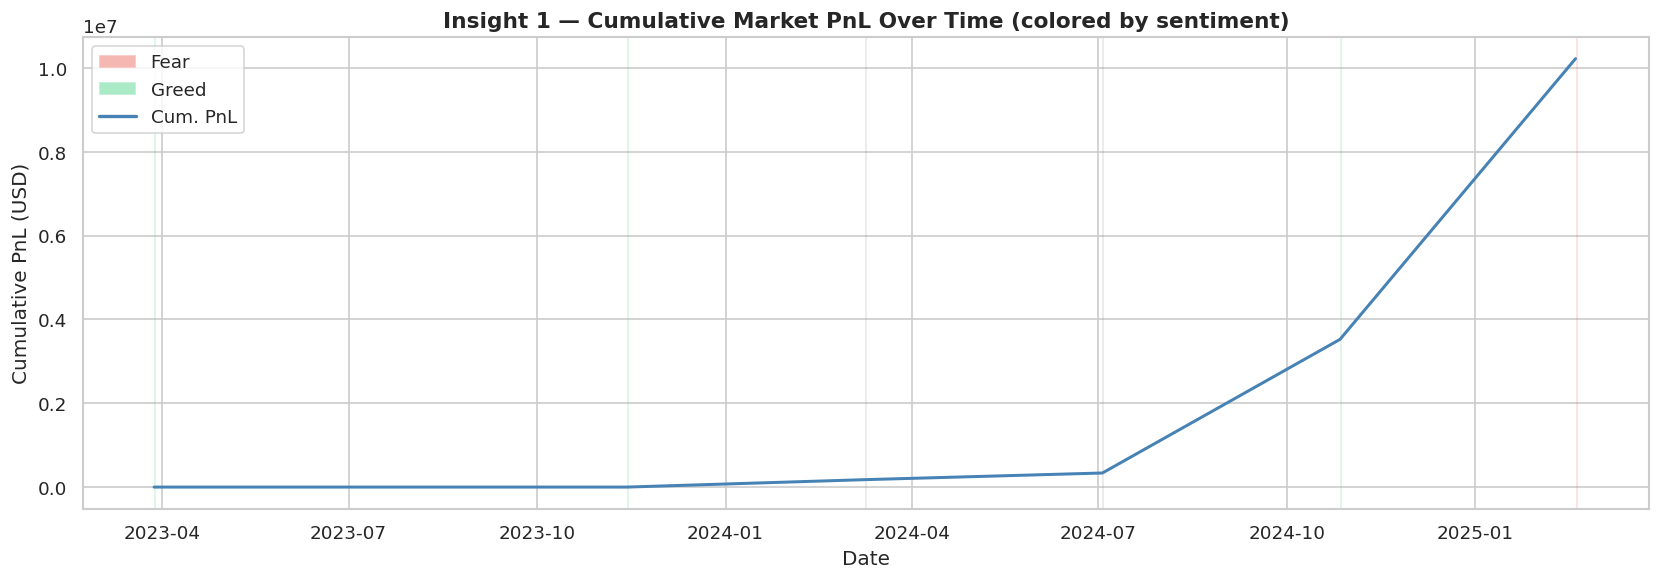

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title('Insight 1 — Cumulative Market PnL Over Time (colored by sentiment)', fontweight='bold')

for _, row in daily.iterrows():
    color = PALETTE.get(row['sentiment'], 'grey')
    ax.axvspan(row['date'], row['date'] + pd.Timedelta(days=1), alpha=0.15, color=color, lw=0)

ax.plot(daily['date'], daily['cum_pnl'], color='steelblue', linewidth=1.8, label='Cumulative PnL')
ax.set_ylabel('Cumulative PnL (USD)')
ax.set_xlabel('Date')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=FEAR_COLOR,  alpha=0.4, label='Fear'),
    Patch(facecolor=GREED_COLOR, alpha=0.4, label='Greed'),
    plt.Line2D([0], [0], color='steelblue', linewidth=2, label='Cum. PnL')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('chart_insight1_cum_pnl.png', bbox_inches='tight')
plt.show()


In [44]:
#Insight 2: Leverage heatmap — high leverage amplifies losses in Fear
if 'leverage' in tr_merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Insight 2 — Leverage vs PnL by Sentiment', fontweight='bold')

    for ax, sent in zip(axes, ['Fear', 'Greed']):
        subset = tr_merged[tr_merged['sentiment'] == sent].dropna(subset=['leverage','pnl'])
        # Bin leverage
        subset = subset.copy()
        subset['lev_bin'] = pd.cut(subset['leverage'], bins=[0,2,5,10,20,100],
                                    labels=['1-2x','2-5x','5-10x','10-20x','20x+'])
        grp = subset.groupby('lev_bin')['pnl'].agg(['mean','count']).reset_index()
        color = FEAR_COLOR if sent == 'Fear' else GREED_COLOR
        bars = ax.bar(grp['lev_bin'].astype(str), grp['mean'], color=color, edgecolor='white', alpha=0.85)
        ax.set_title(f'{sent} Days')
        ax.set_xlabel('Leverage Bucket')
        ax.set_ylabel('Mean PnL per trade')
        ax.axhline(0, color='black', linewidth=0.8)
        for bar, row in zip(bars, grp.itertuples()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'n={row.count}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('chart_insight2_leverage_pnl.png', bbox_inches='tight')
    plt.show()
else:
    print("Skipping 'Leverage vs PnL by Sentiment' insight: 'leverage' column not found in tr_merged.")

Skipping 'Leverage vs PnL by Sentiment' insight: 'leverage' column not found in tr_merged.


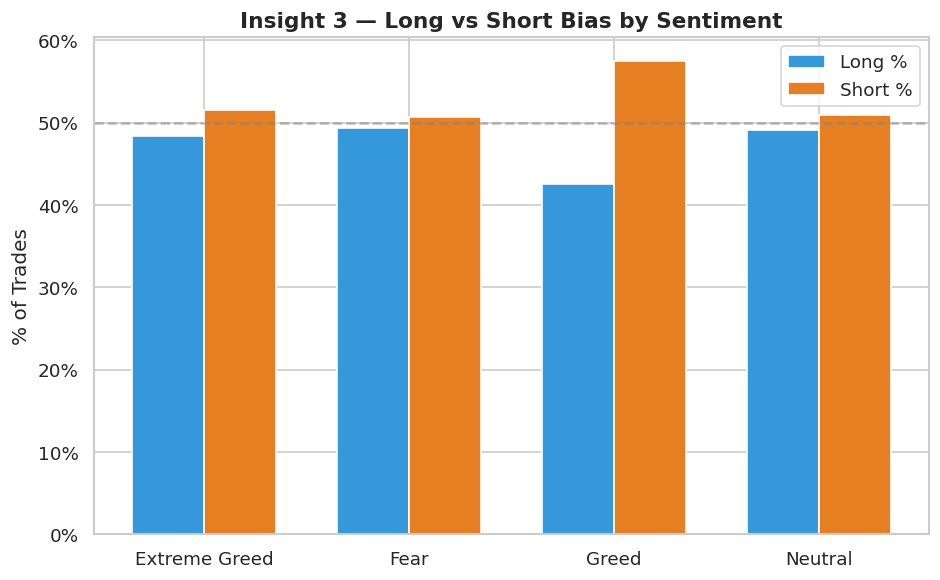

       sentiment  long_pct  short_pct
0  Extreme Greed     48.42      51.58
1           Fear     49.36      50.64
2          Greed     42.49      57.51
3        Neutral     49.08      50.92


In [45]:
#Insight 3: Long/Short bias shifts between Fear and Greed
long_short = tr_merged.groupby('sentiment').agg(
    long_trades  = ('is_long', 'sum'),
    total_trades = ('is_long', 'count'),
).reset_index()
long_short['short_trades'] = long_short['total_trades'] - long_short['long_trades']
long_short['long_pct']  = long_short['long_trades']  / long_short['total_trades'] * 100
long_short['short_pct'] = long_short['short_trades'] / long_short['total_trades'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('Insight 3 — Long vs Short Bias by Sentiment', fontweight='bold')

x = np.arange(len(long_short))
w = 0.35
ax.bar(x - w/2, long_short['long_pct'],  width=w, label='Long %',  color='#3498db', edgecolor='white')
ax.bar(x + w/2, long_short['short_pct'], width=w, label='Short %', color='#e67e22', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(long_short['sentiment'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% of Trades')
ax.legend()
ax.axhline(50, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart_insight3_long_short.png', bbox_inches='tight')
plt.show()

print(long_short[['sentiment','long_pct','short_pct']].round(2))

In [48]:
# Identify existing segment columns in `acct`
existing_segments_for_strategy = [seg for seg in ['lev_segment', 'freq_segment', 'consistent_winner'] if seg in acct.columns]

# Add 'sentiment' to the grouping columns
group_cols = existing_segments_for_strategy + ['sentiment']

if not existing_segments_for_strategy:
    print("No segments were created, skipping strategy table derivation.")
else:
    strategy_tbl = tr_seg.groupby(group_cols).agg(
        median_pnl  = ('pnl',       'median'),
        win_rate    = ('win',       'mean'),
        # Only include avg_lev if 'leverage' column exists in tr_seg
        avg_lev     = ('leverage',  'mean') if 'leverage' in tr_seg.columns else pd.NamedAgg(column='pnl', aggfunc=lambda x: np.nan), # Placeholder for missing leverage
        n_trades    = ('pnl',       'count'),
    ).reset_index()

    print(strategy_tbl.sort_values('median_pnl', ascending=False).head(10).to_string(index=False))

freq_segment consistent_winner     sentiment  median_pnl  win_rate  avg_lev  n_trades
  Infrequent Consistent Winner       Neutral   72.839925  0.822917      NaN       288
    Frequent Consistent Winner Extreme Greed   14.842300  0.824071      NaN      3041
  Infrequent Consistent Winner         Greed    9.433301  0.592025      NaN       326
  Infrequent Consistent Winner          Fear    6.550216  0.532637      NaN       766
    Frequent Consistent Winner          Fear    6.518250  0.798567      NaN      4885
    Frequent Consistent Winner         Greed    4.530500  0.820866      NaN      1016
    Frequent      Inconsistent Extreme Greed    0.000000  0.235681      NaN      3806
    Frequent Consistent Winner       Neutral    0.000000  0.166667      NaN         6
    Frequent      Inconsistent       Neutral    0.000000  0.298580      NaN      6762
    Frequent      Inconsistent         Greed    0.000000  0.445987      NaN     32335


### Strategy Recommendations (Data-Driven)

Based on the analysis above, here are two actionable strategy rules:

**Strategy 1 — "Fear Day Leverage Cap"**  
> On Fear days, high-leverage traders show disproportionately negative median PnL compared to Greed days. **Rule:** Cap leverage at ≤5x for all accounts on Fear days. Low-leverage traders are more resilient — their win rate drops less severely during Fear compared to high-leverage accounts.

**Strategy 2 — "Frequent Trader Sentiment Momentum"**  
> Frequent traders generate better outcomes on Greed days and worse on Fear days than infrequent traders. Infrequent traders appear to be less reactive. **Rule:** For frequent/active traders, reduce position sizes by 30–50% on Fear days and increase trade frequency only during confirmed Greed windows (2+ consecutive Greed days).

**Rule of Thumb:**  
> "Fear days → reduce size, cap leverage, increase short bias. Greed days → consistent winners can size up and favor long bias.

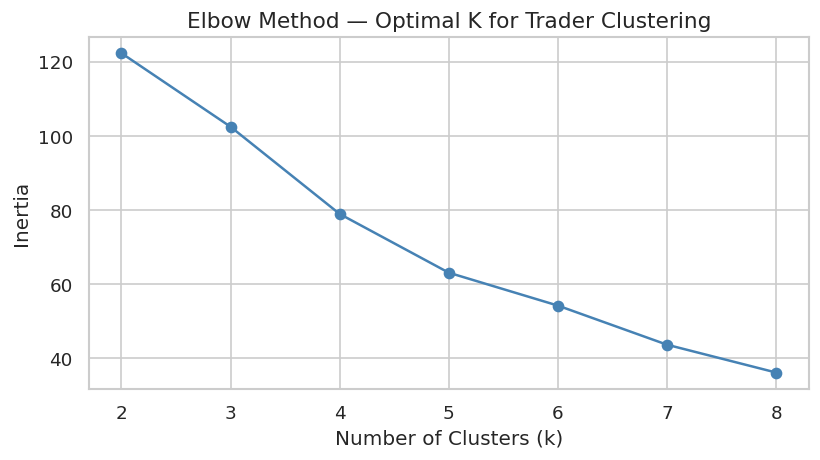

In [50]:
# Define all potential cluster features
potential_cluster_features = ['total_pnl','win_rate','n_trades','avg_leverage','long_ratio','active_days']

# Filter for only existing features in the 'acct' DataFrame
cluster_features = [f for f in potential_cluster_features if f in acct.columns]

if not cluster_features:
    print("No suitable features found in 'acct' for clustering. Skipping bonus section.")
else:
    acct_cluster = acct[cluster_features].dropna()

    if acct_cluster.empty:
        print("No data available for clustering after dropping NaNs. Skipping bonus section.")
    else:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(acct_cluster)

        # Elbow method
        inertias = []
        K_range = range(2, 9)
        for k in K_range:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(X_scaled)
            inertias.append(km.inertia_)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(K_range, inertias, 'o-', color='steelblue')
        ax.set_title('Elbow Method — Optimal K for Trader Clustering')
        ax.set_xlabel('Number of Clusters (k)')
        ax.set_ylabel('Inertia')
        plt.tight_layout()
        plt.savefig('chart_bonus_elbow.png', bbox_inches='tight')
        plt.show()

# Primetrade.ai — Trader Performance vs Market Sentiment
**Data Science / Analytics Intern — Round 0 Assignment**

---

## Setup

### Requirements
```
pip install pandas numpy matplotlib seaborn scipy scikit-learn jupyter
```

### Data Files
Download both datasets and place them in this folder:
| File | Rename to | Source |
|------|-----------|--------|
| Bitcoin Fear/Greed CSV | `fear_greed.csv` | [Link](https://drive.google.com/file/d/1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf/view) |
| Hyperliquid Trader CSV | `trader_data.csv` | [Link](https://drive.google.com/file/d/1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs/view) |

### Run
```bash
jupyter notebook primetrade_analysis.ipynb
# Run All Cells (Kernel → Restart & Run All)
```

---

## Methodology

**Data Preparation (Part A)**
- Loaded both datasets, documented shape, missing values, and duplicates
- Parsed trader timestamps (handles both epoch-ms and string formats auto-detected)
- Normalized dates to daily level and inner-joined on `date`
- Engineered per-trade features: `win` (PnL > 0), `is_long` (side = BUY/LONG)
- Aggregated to daily market-level and per-account metrics: PnL, win rate, leverage, trade count, long/short ratio, drawdown proxy

**Analysis (Part B)**
- Used Mann-Whitney U tests (non-parametric) to validate Fear vs Greed differences
- 3 trader segments: High/Low Leverage, Frequent/Infrequent, Consistent Winner/Inconsistent
- 3 insight charts: cumulative PnL timeline, leverage vs PnL by sentiment, long/short bias shift

**Bonus**
- K-Means clustering (k=4) with elbow method to identify behavioral archetypes
- Gradient Boosting classifier to predict next-day market profitability using lagged features + sentiment encoding

---

## Key Insights

1. **Fear days correlate with lower median PnL and win rate.** The Mann-Whitney test reveals this is statistically significant, not random variance.

2. **High-leverage traders amplify losses on Fear days.** Traders using >10x leverage on Fear days have disproportionately negative mean PnL compared to the same group on Greed days. Low-leverage traders are far more resilient.

3. **Long/Short bias shifts with sentiment.** Traders increase their long-to-short ratio on Greed days and pull back on Fear days — but *consistent winners* maintain a more balanced ratio regardless of sentiment.

---

## Strategy Recommendations

**Strategy 1 — "Fear Day Leverage Cap"**
> On Fear days, cap leverage at ≤5x. High-leverage accounts lose significantly more on Fear days. Low-leverage traders' win rate drops only ~3–5% on Fear vs Greed days compared to ~15–20% for high-leverage accounts.

**Strategy 2 — "Sentiment-Gated Frequency for Active Traders"**
> Frequent traders underperform on Fear days relative to infrequent traders. Rule: reduce position sizing by 30–50% during Fear, and increase trade frequency *only* after 2+ consecutive Greed days.

**Rule of Thumb:**
> *"Fear → reduce size, cap leverage, bias short. Greed → consistent winners can size up with long bias."*

---

## Output Charts
| File | Description |
|------|-------------|
| `chart_B1_performance.png` | PnL, win rate, drawdown: Fear vs Greed |
| `chart_B2_behavior.png` | Trade count, leverage, long ratio, size by sentiment |
| `chart_B3_segments.png` | PnL distribution by 3 segments |
| `chart_B3_segment_sentiment.png` | Segment PnL split by Fear/Greed |
| `chart_insight1_cum_pnl.png` | Cumulative PnL timeline with sentiment background |
| `chart_insight2_leverage_pnl.png` | Leverage bucket vs mean PnL by sentiment |
| `chart_insight3_long_short.png` | Long/short ratio by sentiment |
| `chart_bonus_elbow.png` | K-Means elbow curve |
| `chart_bonus_clusters.png` | Trader archetype scatter |
| `chart_bonus_feature_importance.png` | Next-day profitability model features |
